#Pengolahan Citra Digital
**Tugas Individu — Implementasi Konsep Dasar Pengolahan Citra Digital**

---
**Nama:** Noval Suprayoga

**NIM:** 312410305

**Kelas:** I246A

---
### Daftar Isi
1. Setup & Import Library
2. Load Gambar
3. Konversi RGB ke Grayscale
4. Brightness Adjustment & Contrast Enhancement
5. Transformasi Geometri (Translasi, Rotasi, Scaling, Flipping)
6. Histogram Equalization
7. Filtering Spasial (Smoothing & Sharpening)

---
## 📦 1. Setup & Import Library

In [ ]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
from google.colab import files

def tampilkan_dua(img1, img2, judul1='Gambar 1', judul2='Gambar 2', cmap1=None, cmap2=None):
    fig, axes = plt.subplots(1, 2, figsize=(12, 5))
    axes[0].imshow(img1, cmap=cmap1); axes[0].set_title(judul1, fontsize=13, fontweight='bold'); axes[0].axis('off')
    axes[1].imshow(img2, cmap=cmap2); axes[1].set_title(judul2, fontsize=13, fontweight='bold'); axes[1].axis('off')
    plt.tight_layout(); plt.show()

def tampilkan_empat(imgs, titles, cmaps=None):
    fig, axes = plt.subplots(1, 4, figsize=(20, 5))
    for i, (img, title) in enumerate(zip(imgs, titles)):
        cmap = cmaps[i] if cmaps else None
        axes[i].imshow(img, cmap=cmap); axes[i].set_title(title, fontsize=11, fontweight='bold'); axes[i].axis('off')
    plt.tight_layout(); plt.show()

print('✅ Library berhasil diimport!')

✅ Library berhasil diimport!


**Penjelasan:**
Library yang digunakan:
- `OpenCV (cv2)` — library utama pengolahan citra
- `NumPy` — operasi matriks pada data piksel
- `Matplotlib` — menampilkan gambar dan grafik
- `google.colab.files` — upload gambar dari komputer lokal

---
## 🗂️ 2. Upload & Load Gambar

In [ ]:
print('📤 Upload Gambar 1...')
uploaded1 = files.upload()

📤 Upload Gambar 1...


Saving Logo-Liverpool-FC.png to Logo-Liverpool-FC.png


In [ ]:
print('📤 Upload Gambar 2...')
uploaded2 = files.upload()

📤 Upload Gambar 2...


Saving Logo-Liverpool.png to Logo-Liverpool.png


✅ Gambar 1: Logo-Liverpool-FC.png | Ukuran: (1440, 1920, 3)
✅ Gambar 2: Logo-Liverpool.png | Ukuran: (2400, 3840, 3)


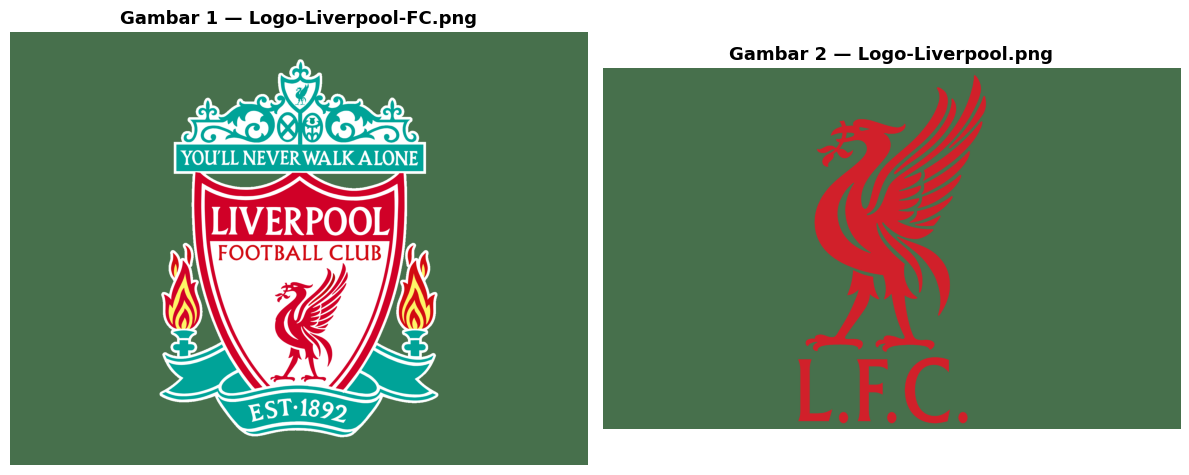

In [ ]:
nama_file1 = list(uploaded1.keys())[0]
nama_file2 = list(uploaded2.keys())[0]

img1_bgr = cv2.imread(nama_file1)
img2_bgr = cv2.imread(nama_file2)

img1 = cv2.cvtColor(img1_bgr, cv2.COLOR_BGR2RGB)
img2 = cv2.cvtColor(img2_bgr, cv2.COLOR_BGR2RGB)

print(f'✅ Gambar 1: {nama_file1} | Ukuran: {img1.shape}')
print(f'✅ Gambar 2: {nama_file2} | Ukuran: {img2.shape}')

tampilkan_dua(img1, img2,
              judul1=f'Gambar 1 — {nama_file1}',
              judul2=f'Gambar 2 — {nama_file2}')

**Penjelasan:**
Gambar dibaca menggunakan `cv2.imread()` yang secara default membaca dalam format **BGR** (Blue-Green-Red). Karena Matplotlib menampilkan gambar dalam format **RGB**, maka perlu dikonversi terlebih dahulu menggunakan `cv2.COLOR_BGR2RGB` agar warna tampil dengan benar.

---
## 🎨 3. Konversi RGB ke Grayscale

**Konsep Dasar:**
Grayscale adalah representasi citra di mana setiap piksel hanya memiliki satu nilai intensitas (0–255), bukan tiga kanal warna (R, G, B).

Formula konversi: **Y = 0.299×R + 0.587×G + 0.114×B**

Bobot berbeda karena mata manusia lebih sensitif terhadap warna hijau dibandingkan merah dan biru.

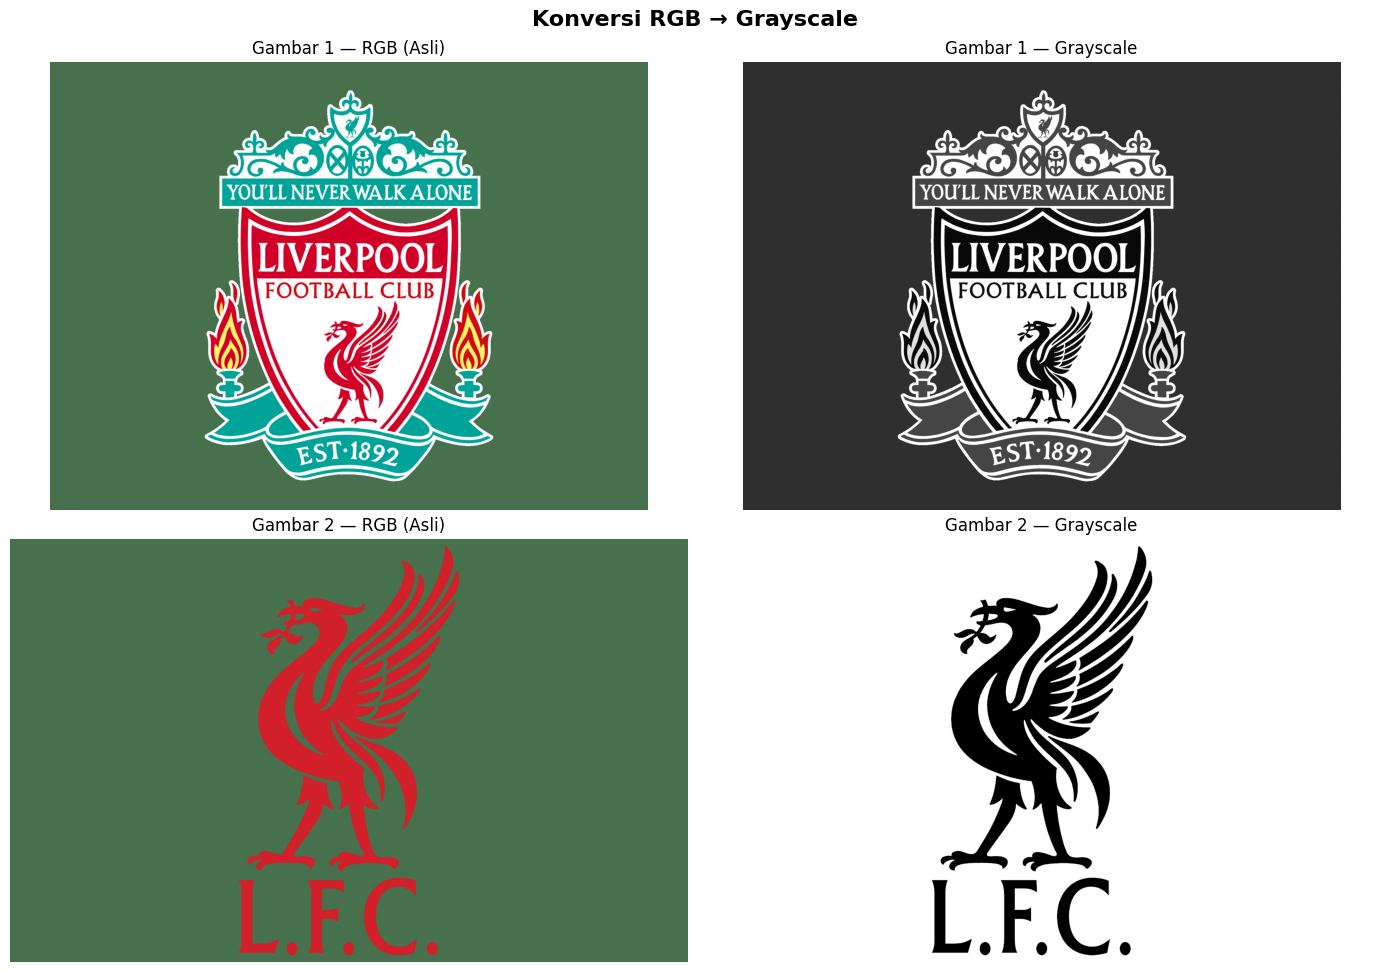

In [ ]:
gray1 = cv2.cvtColor(img1, cv2.COLOR_RGB2GRAY)
gray2 = cv2.cvtColor(img2, cv2.COLOR_RGB2GRAY)

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('Konversi RGB → Grayscale', fontsize=16, fontweight='bold')

axes[0][0].imshow(img1);            axes[0][0].set_title('Gambar 1 — RGB (Asli)');   axes[0][0].axis('off')
axes[0][1].imshow(gray1, cmap='gray'); axes[0][1].set_title('Gambar 1 — Grayscale'); axes[0][1].axis('off')
axes[1][0].imshow(img2);            axes[1][0].set_title('Gambar 2 — RGB (Asli)');   axes[1][0].axis('off')
axes[1][1].imshow(gray2, cmap='gray'); axes[1][1].set_title('Gambar 2 — Grayscale'); axes[1][1].axis('off')

plt.tight_layout()
plt.show()

**Penjelasan Hasil:**
`cv2.cvtColor(img, cv2.COLOR_RGB2GRAY)` mengkonversi gambar 3 kanal (R, G, B) menjadi 1 kanal intensitas abu-abu. Shape gambar berubah dari `(H, W, 3)` menjadi `(H, W)`. Gambar grayscale lebih ringan secara komputasi dan sering digunakan sebagai langkah awal sebelum pemrosesan lebih lanjut.

---
## ☀️ 4. Brightness Adjustment & Contrast Enhancement

**Konsep Dasar:**
Formula: **output = α × input + β**
- **α (alpha)** = faktor kontras. `α > 1` → kontras naik, `α < 1` → kontras turun
- **β (beta)** = faktor brightness. `β > 0` → lebih terang, `β < 0` → lebih gelap

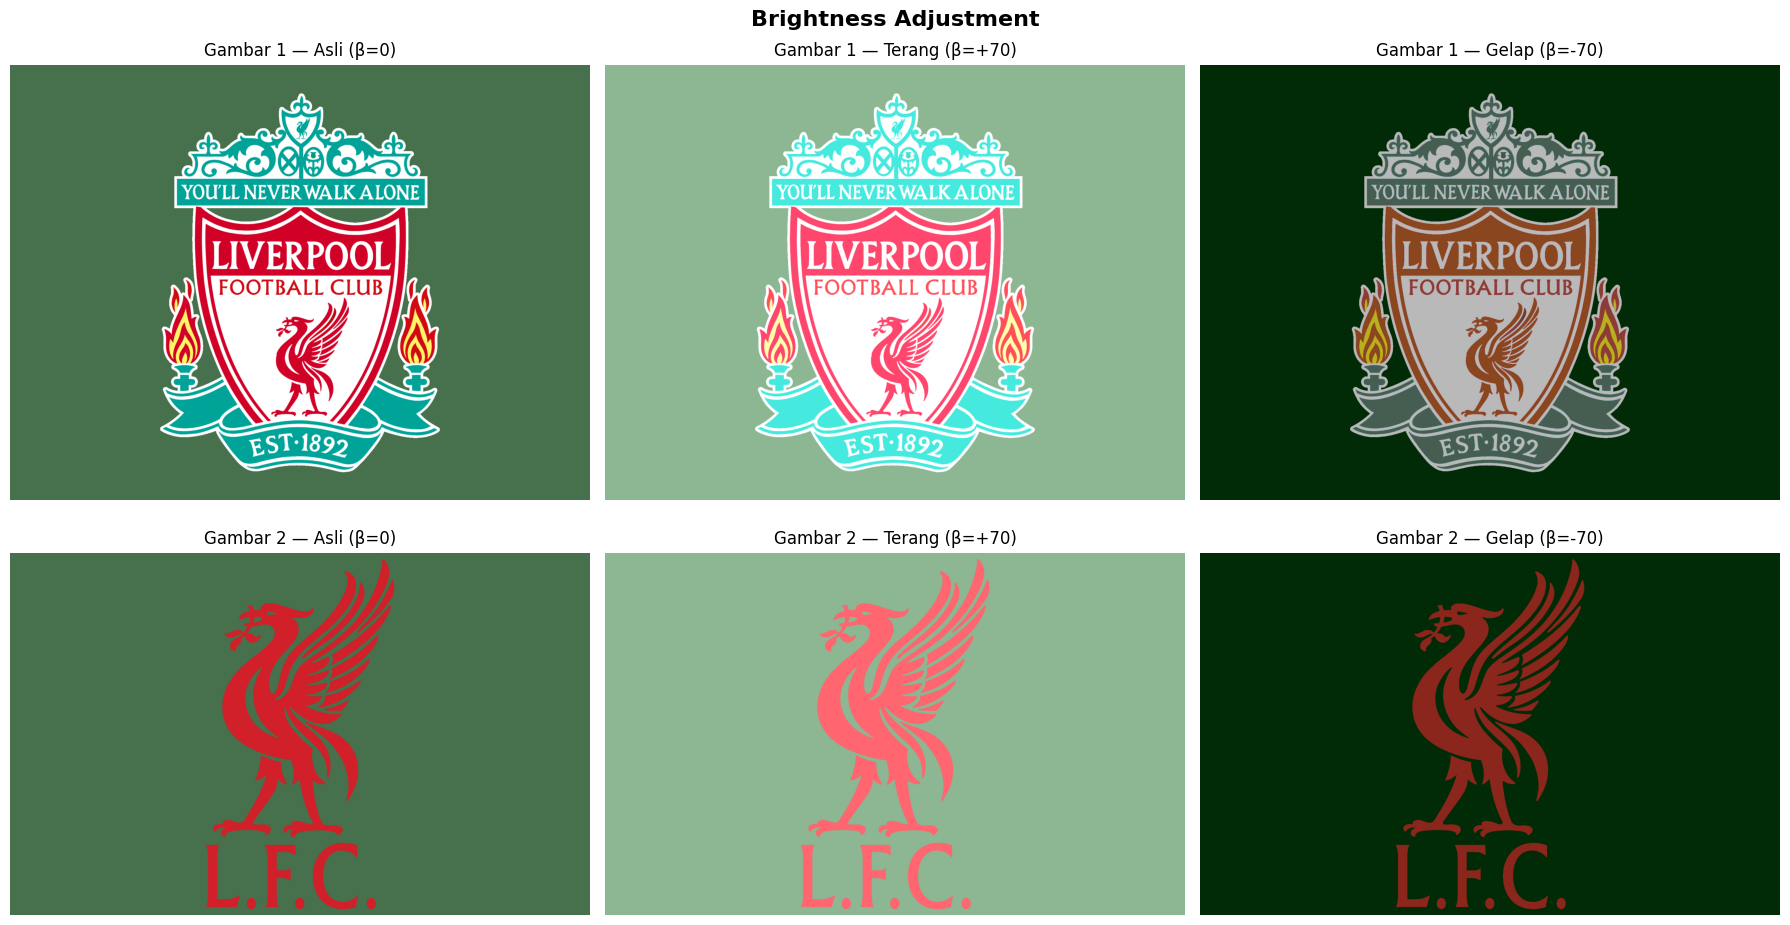

In [ ]:
# Brightness Adjustment
img1_bright = cv2.convertScaleAbs(img1, alpha=1.0, beta=70)
img1_dark   = cv2.convertScaleAbs(img1, alpha=1.0, beta=-70)
img2_bright = cv2.convertScaleAbs(img2, alpha=1.0, beta=70)
img2_dark   = cv2.convertScaleAbs(img2, alpha=1.0, beta=-70)

fig, axes = plt.subplots(2, 3, figsize=(18, 10))
fig.suptitle('Brightness Adjustment', fontsize=16, fontweight='bold')

for row, (orig, bright, dark, label) in enumerate([
    (img1, img1_bright, img1_dark, 'Gambar 1'),
    (img2, img2_bright, img2_dark, 'Gambar 2')
]):
    axes[row][0].imshow(orig);   axes[row][0].set_title(f'{label} — Asli (β=0)');     axes[row][0].axis('off')
    axes[row][1].imshow(bright); axes[row][1].set_title(f'{label} — Terang (β=+70)'); axes[row][1].axis('off')
    axes[row][2].imshow(dark);   axes[row][2].set_title(f'{label} — Gelap (β=-70)');  axes[row][2].axis('off')

plt.tight_layout()
plt.show()

**Penjelasan Hasil — Brightness:**
Nilai beta ditambahkan ke setiap piksel gambar. `beta=+70` membuat semua piksel naik 70 sehingga gambar menjadi lebih terang. `beta=-70` membuat semua piksel turun 70 sehingga gambar menjadi lebih gelap. Fungsi `cv2.convertScaleAbs()` secara otomatis mem-*clip* nilai agar tetap dalam range 0–255.

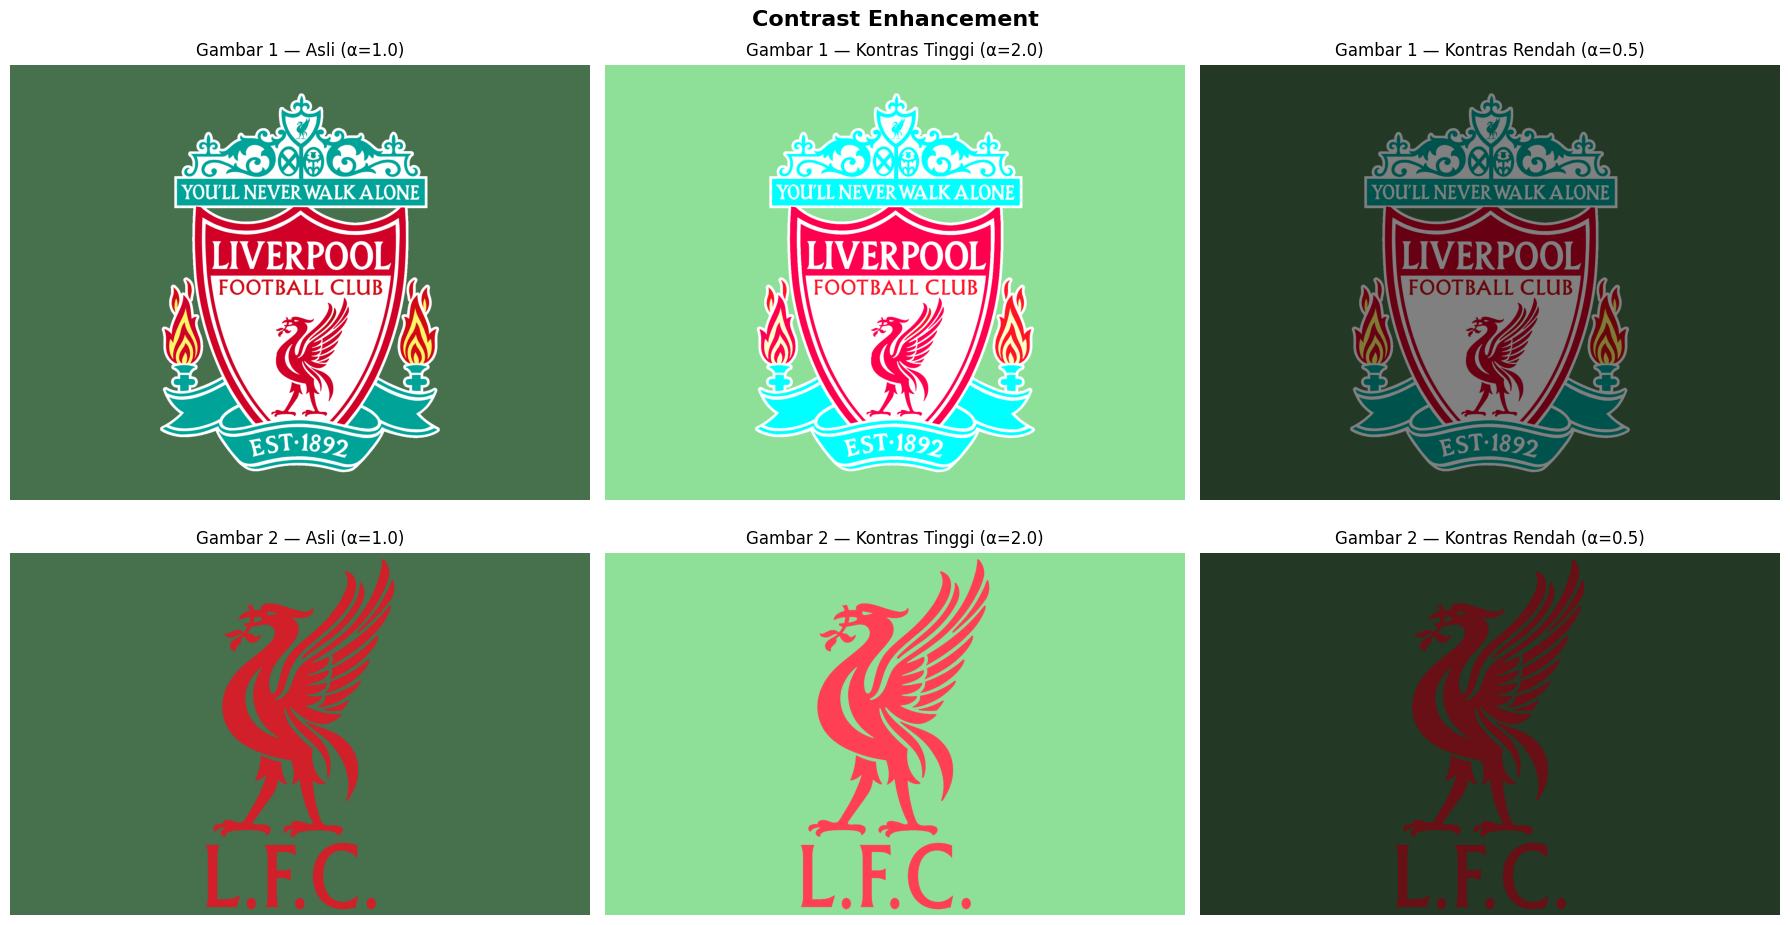

In [ ]:
# Contrast Enhancement
img1_high_contrast = cv2.convertScaleAbs(img1, alpha=2.0, beta=0)
img1_low_contrast  = cv2.convertScaleAbs(img1, alpha=0.5, beta=0)
img2_high_contrast = cv2.convertScaleAbs(img2, alpha=2.0, beta=0)
img2_low_contrast  = cv2.convertScaleAbs(img2, alpha=0.5, beta=0)

fig, axes = plt.subplots(2, 3, figsize=(18, 10))
fig.suptitle('Contrast Enhancement', fontsize=16, fontweight='bold')

for row, (orig, high, low, label) in enumerate([
    (img1, img1_high_contrast, img1_low_contrast, 'Gambar 1'),
    (img2, img2_high_contrast, img2_low_contrast, 'Gambar 2')
]):
    axes[row][0].imshow(orig); axes[row][0].set_title(f'{label} — Asli (α=1.0)');           axes[row][0].axis('off')
    axes[row][1].imshow(high); axes[row][1].set_title(f'{label} — Kontras Tinggi (α=2.0)'); axes[row][1].axis('off')
    axes[row][2].imshow(low);  axes[row][2].set_title(f'{label} — Kontras Rendah (α=0.5)'); axes[row][2].axis('off')

plt.tight_layout()
plt.show()

**Penjelasan Hasil — Contrast:**
Nilai alpha mengalikan setiap piksel. `alpha=2.0` memperbesar perbedaan antara piksel terang dan gelap sehingga kontras meningkat — warna terlihat lebih "mencolok". `alpha=0.5` memperkecil perbedaan sehingga gambar terlihat "flat" atau pucat. Kontras yang tepat membuat detail gambar lebih mudah terlihat.

---
## 🔄 5. Transformasi Geometri

**Konsep Dasar:**
Transformasi geometri mengubah posisi, ukuran, atau orientasi piksel menggunakan operasi matriks. Setiap piksel baru dihitung dari posisi piksel lama berdasarkan matriks transformasi.

### 5.1 Translasi

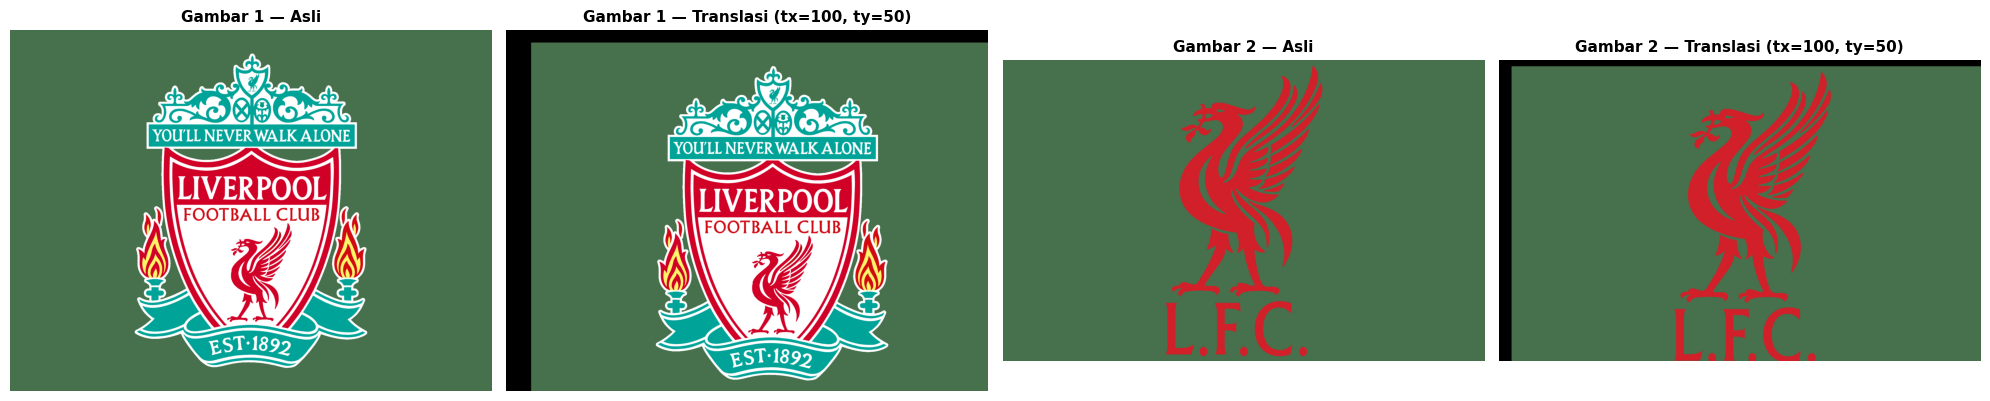

In [ ]:
def translasi(img, tx, ty):
    h, w = img.shape[:2]
    M = np.float32([[1, 0, tx],
                    [0, 1, ty]])
    return cv2.warpAffine(img, M, (w, h))

img1_trans = translasi(img1, tx=100, ty=50)
img2_trans = translasi(img2, tx=100, ty=50)

tampilkan_empat(
    [img1, img1_trans, img2, img2_trans],
    ['Gambar 1 — Asli', 'Gambar 1 — Translasi (tx=100, ty=50)',
     'Gambar 2 — Asli', 'Gambar 2 — Translasi (tx=100, ty=50)']
)

**Penjelasan Hasil — Translasi:**
Translasi menggeser posisi gambar menggunakan matriks transformasi affine `M = [[1,0,tx],[0,1,ty]]`. Nilai `tx=100` menggeser gambar 100 piksel ke kanan, dan `ty=50` menggeser 50 piksel ke bawah. Area yang ditinggalkan terisi warna hitam (piksel bernilai 0).

### 5.2 Rotasi

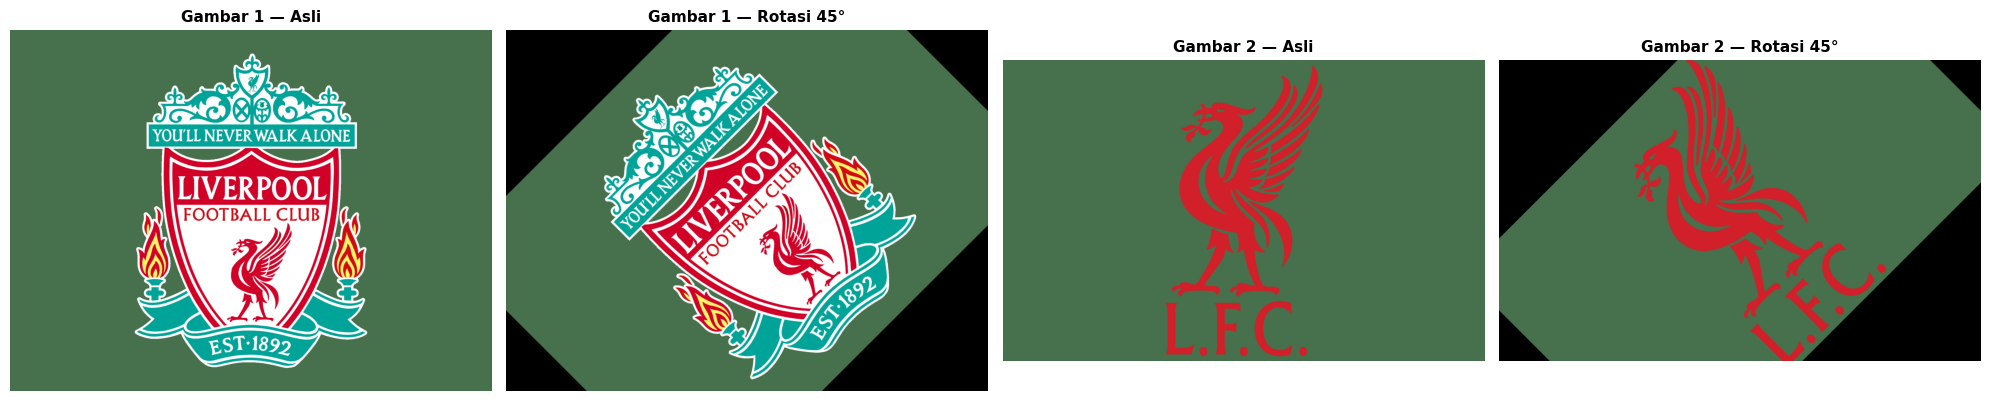

In [ ]:
def rotasi(img, sudut):
    h, w = img.shape[:2]
    cx, cy = w // 2, h // 2
    M = cv2.getRotationMatrix2D((cx, cy), sudut, scale=1.0)
    return cv2.warpAffine(img, M, (w, h))

img1_rot = rotasi(img1, 45)
img2_rot = rotasi(img2, 45)

tampilkan_empat(
    [img1, img1_rot, img2, img2_rot],
    ['Gambar 1 — Asli', 'Gambar 1 — Rotasi 45°',
     'Gambar 2 — Asli', 'Gambar 2 — Rotasi 45°']
)

**Penjelasan Hasil — Rotasi:**
`cv2.getRotationMatrix2D(center, angle, scale)` menghasilkan matriks rotasi 2×3. Pusat rotasi ditentukan di titik tengah gambar `(cx, cy)`. Sudut positif memutar gambar berlawanan arah jarum jam. Area yang tidak terisi setelah rotasi akan berwarna hitam.

### 5.3 Scaling

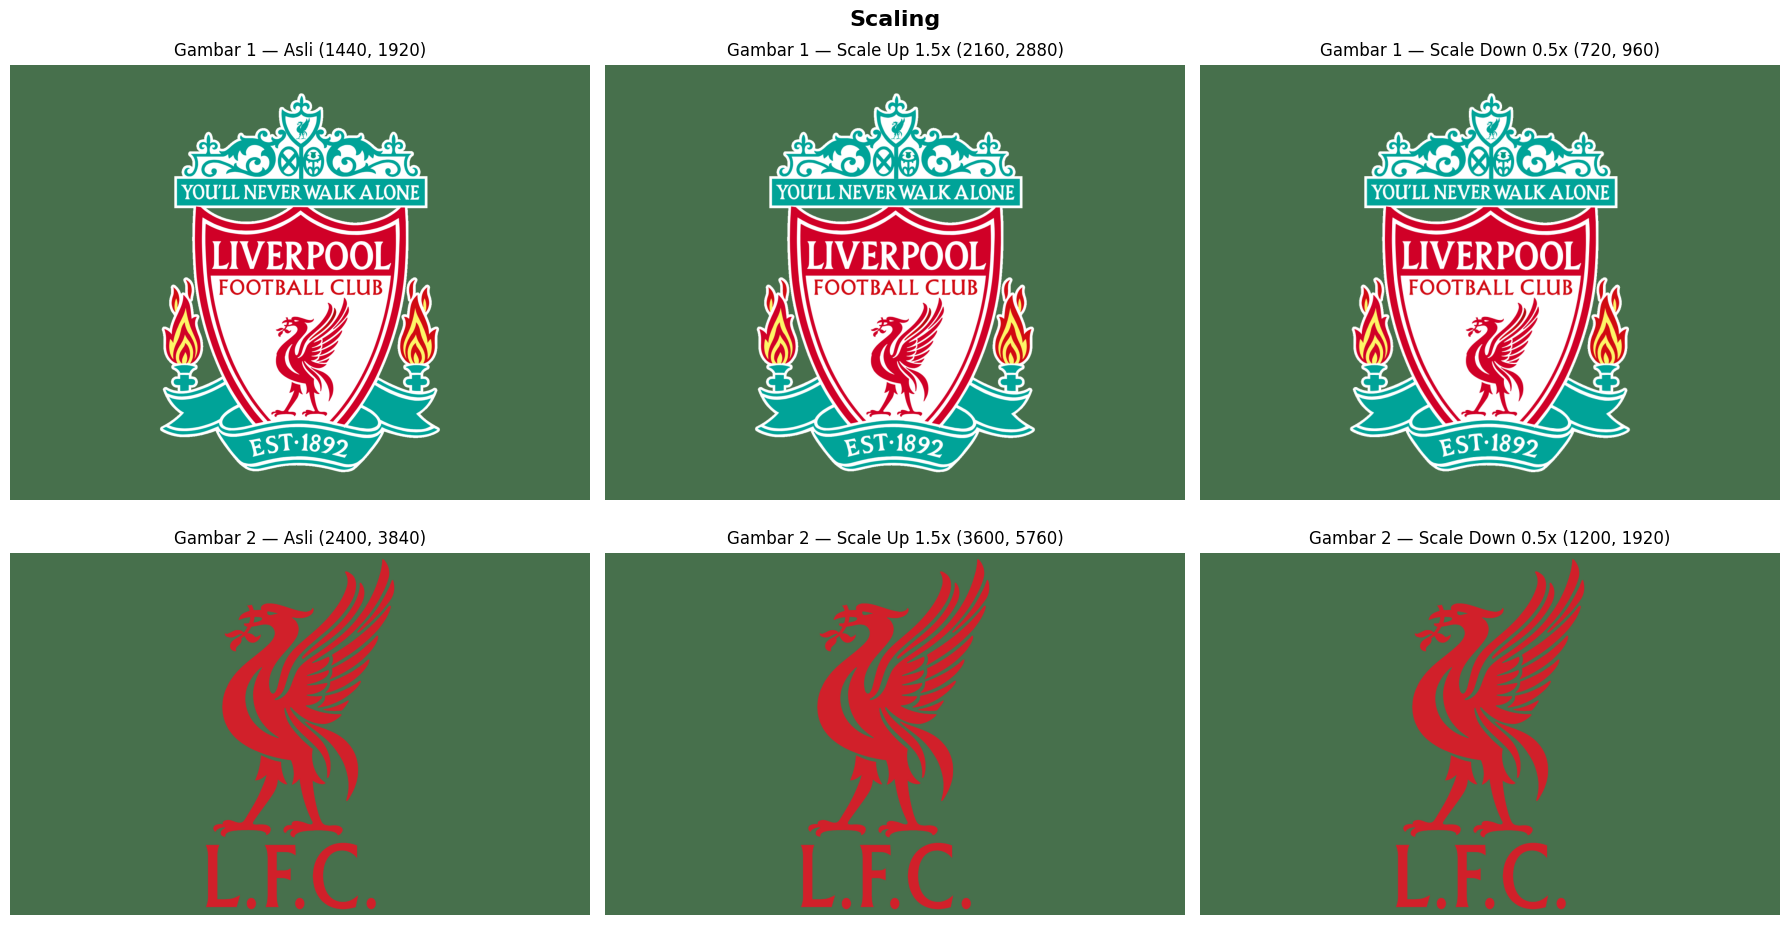

In [ ]:
h1, w1 = img1.shape[:2]
h2, w2 = img2.shape[:2]

img1_scale_up   = cv2.resize(img1, (int(w1*1.5), int(h1*1.5)), interpolation=cv2.INTER_LINEAR)
img1_scale_down = cv2.resize(img1, (int(w1*0.5), int(h1*0.5)), interpolation=cv2.INTER_LINEAR)
img2_scale_up   = cv2.resize(img2, (int(w2*1.5), int(h2*1.5)), interpolation=cv2.INTER_LINEAR)
img2_scale_down = cv2.resize(img2, (int(w2*0.5), int(h2*0.5)), interpolation=cv2.INTER_LINEAR)

fig, axes = plt.subplots(2, 3, figsize=(18, 10))
fig.suptitle('Scaling', fontsize=16, fontweight='bold')

for row, (orig, up, down, label) in enumerate([
    (img1, img1_scale_up, img1_scale_down, 'Gambar 1'),
    (img2, img2_scale_up, img2_scale_down, 'Gambar 2')
]):
    axes[row][0].imshow(orig); axes[row][0].set_title(f'{label} — Asli {orig.shape[:2]}');             axes[row][0].axis('off')
    axes[row][1].imshow(up);   axes[row][1].set_title(f'{label} — Scale Up 1.5x {up.shape[:2]}');      axes[row][1].axis('off')
    axes[row][2].imshow(down); axes[row][2].set_title(f'{label} — Scale Down 0.5x {down.shape[:2]}'); axes[row][2].axis('off')

plt.tight_layout()
plt.show()

**Penjelasan Hasil — Scaling:**
`cv2.resize()` mengubah dimensi gambar ke ukuran yang ditentukan. `INTER_LINEAR` adalah metode interpolasi bilinear yang menghitung nilai piksel baru berdasarkan rata-rata tertimbang dari 4 piksel terdekat — menghasilkan kualitas yang baik untuk zoom in maupun zoom out.

### 5.4 Flipping

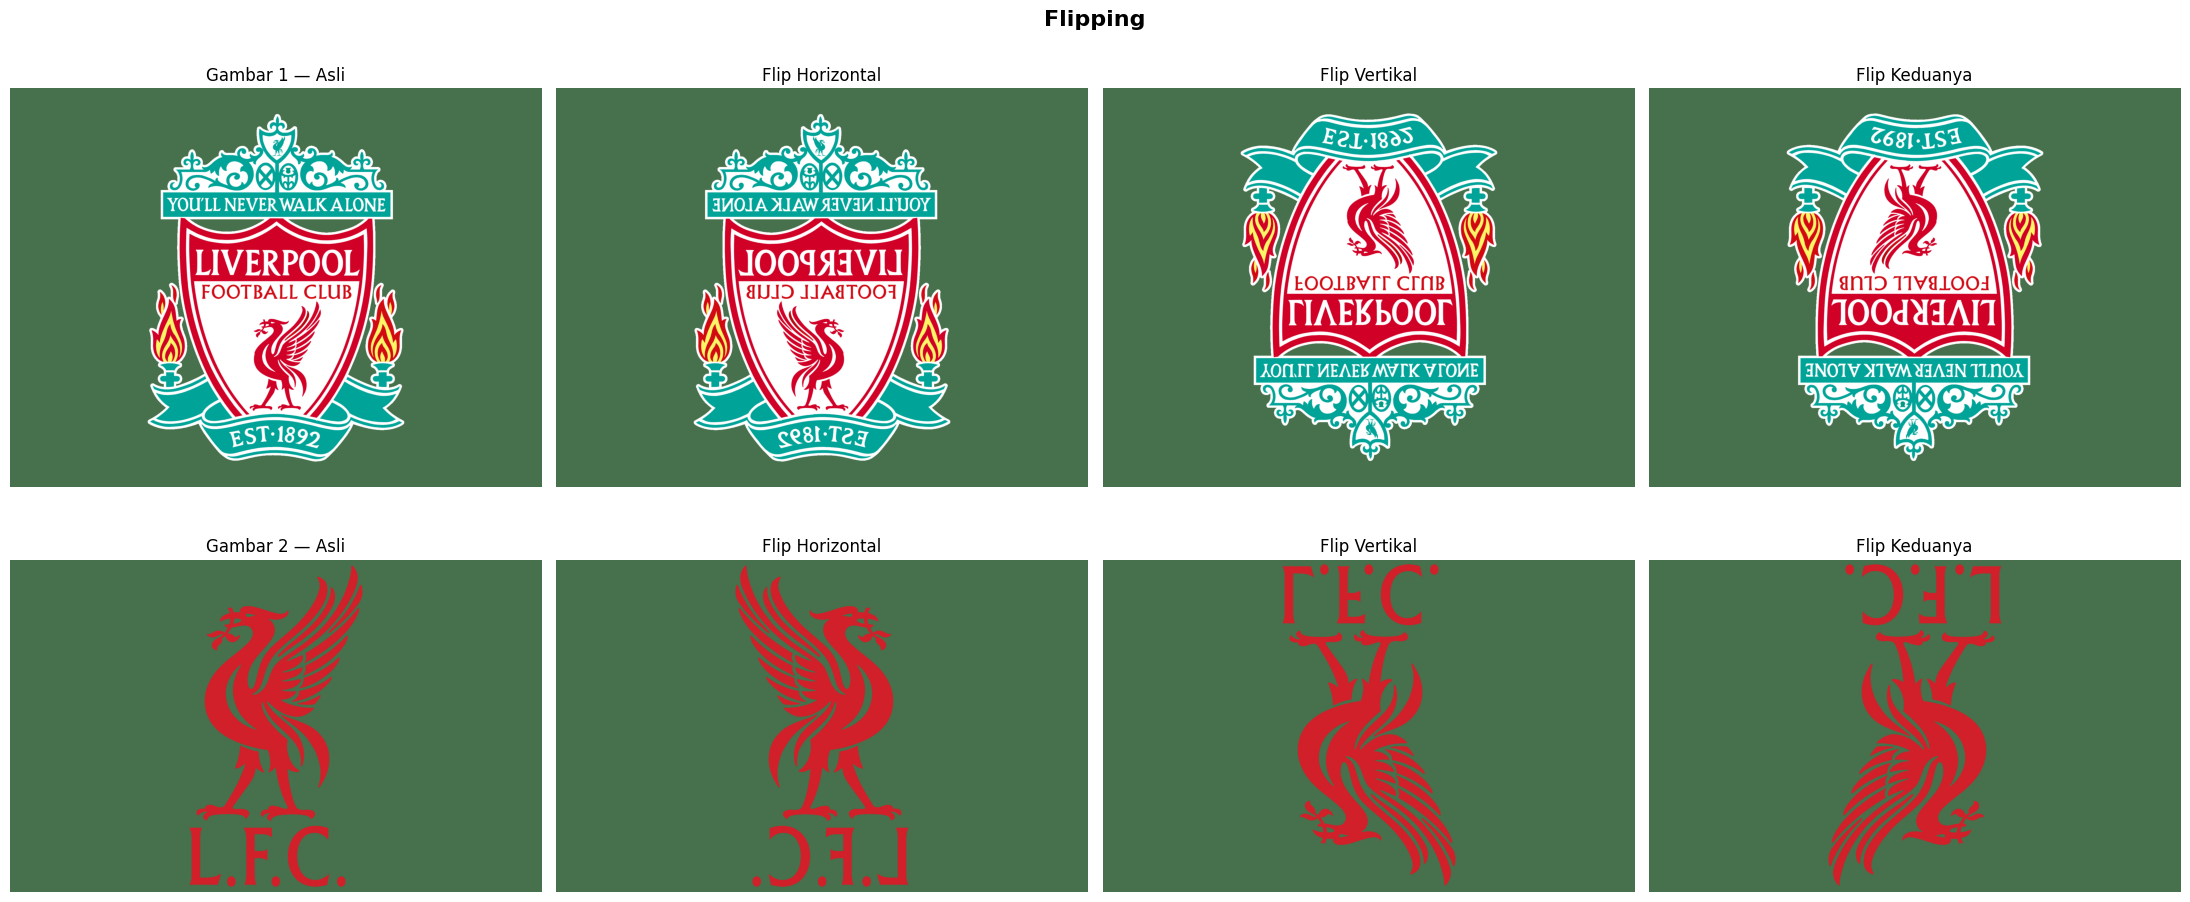

In [ ]:
img1_flip_h = cv2.flip(img1, 1)
img1_flip_v = cv2.flip(img1, 0)
img1_flip_b = cv2.flip(img1, -1)
img2_flip_h = cv2.flip(img2, 1)
img2_flip_v = cv2.flip(img2, 0)
img2_flip_b = cv2.flip(img2, -1)

fig, axes = plt.subplots(2, 4, figsize=(22, 10))
fig.suptitle('Flipping', fontsize=16, fontweight='bold')

for row, (orig, fh, fv, fb, label) in enumerate([
    (img1, img1_flip_h, img1_flip_v, img1_flip_b, 'Gambar 1'),
    (img2, img2_flip_h, img2_flip_v, img2_flip_b, 'Gambar 2')
]):
    axes[row][0].imshow(orig); axes[row][0].set_title(f'{label} — Asli');   axes[row][0].axis('off')
    axes[row][1].imshow(fh);   axes[row][1].set_title('Flip Horizontal');    axes[row][1].axis('off')
    axes[row][2].imshow(fv);   axes[row][2].set_title('Flip Vertikal');       axes[row][2].axis('off')
    axes[row][3].imshow(fb);   axes[row][3].set_title('Flip Keduanya');       axes[row][3].axis('off')

plt.tight_layout()
plt.show()

**Penjelasan Hasil — Flipping:**
`cv2.flip(img, flipCode)` membalik gambar sesuai sumbu:
- `flipCode=1` → cermin **horizontal** (kiri ↔ kanan)
- `flipCode=0` → cermin **vertikal** (atas ↔ bawah)
- `flipCode=-1` → cermin **keduanya** (horizontal + vertikal)

---
## 📊 6. Histogram Equalization

**Konsep Dasar:**
Histogram Equalization meningkatkan kualitas gambar dengan **meratakan distribusi intensitas piksel** di seluruh range 0–255. Cocok untuk gambar yang terlalu gelap atau terlalu terang. Distribusi kumulatif histogram digunakan sebagai fungsi transformasi.

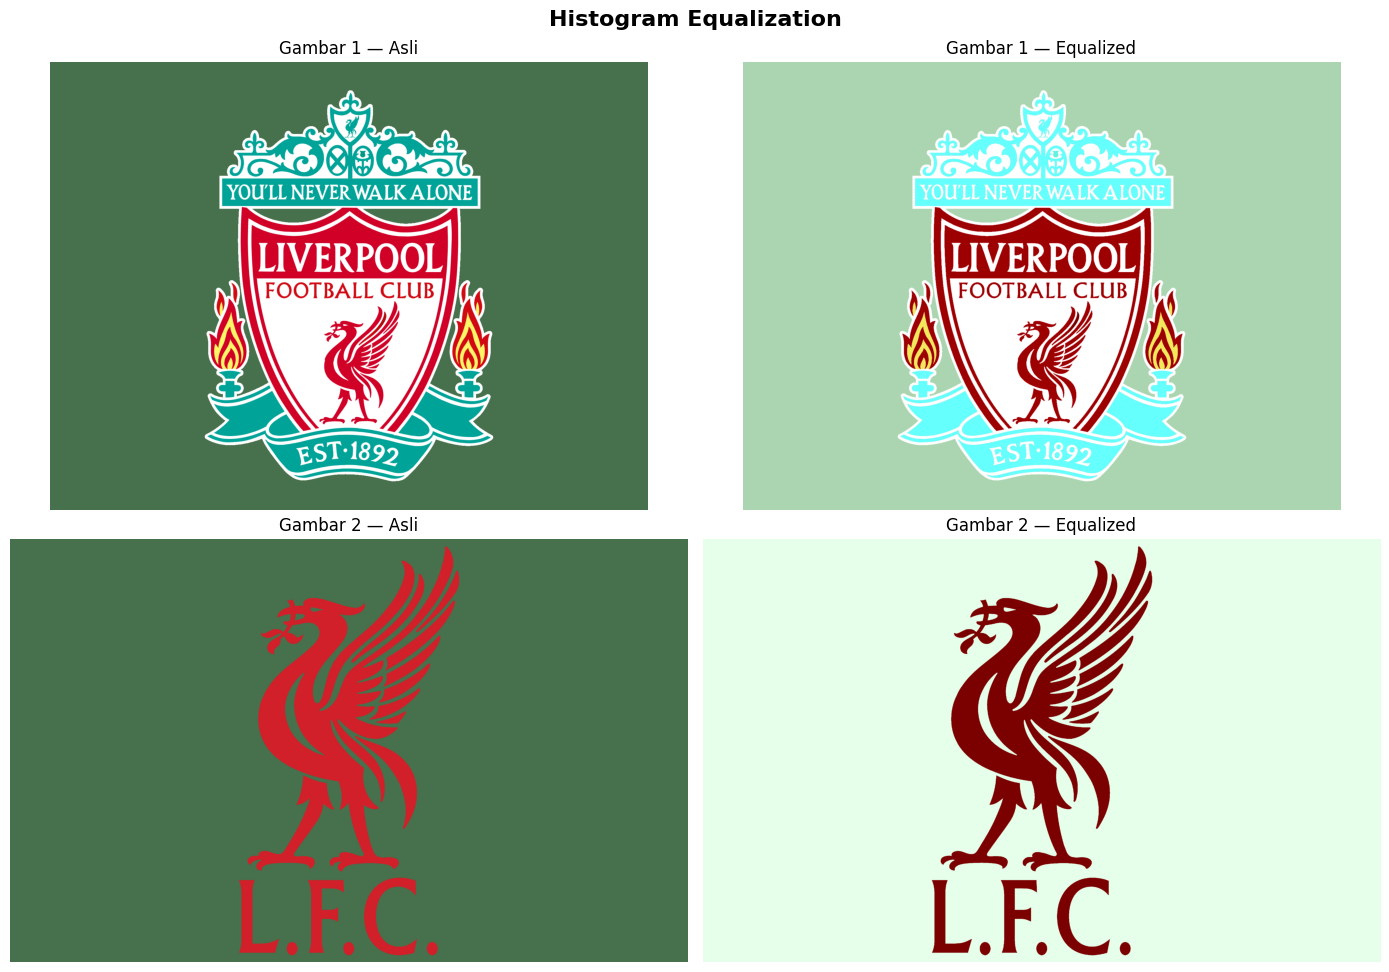

In [ ]:
# Equalize grayscale
gray1_eq = cv2.equalizeHist(gray1)
gray2_eq = cv2.equalizeHist(gray2)

# Equalize gambar berwarna via channel Y pada ruang warna YCrCb
def equalize_color(img_rgb):
    img_ycrcb = cv2.cvtColor(img_rgb, cv2.COLOR_RGB2YCrCb)
    img_ycrcb[:, :, 0] = cv2.equalizeHist(img_ycrcb[:, :, 0])
    return cv2.cvtColor(img_ycrcb, cv2.COLOR_YCrCb2RGB)

img1_eq = equalize_color(img1)
img2_eq = equalize_color(img2)

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('Histogram Equalization', fontsize=16, fontweight='bold')

axes[0][0].imshow(img1);    axes[0][0].set_title('Gambar 1 — Asli');      axes[0][0].axis('off')
axes[0][1].imshow(img1_eq); axes[0][1].set_title('Gambar 1 — Equalized'); axes[0][1].axis('off')
axes[1][0].imshow(img2);    axes[1][0].set_title('Gambar 2 — Asli');      axes[1][0].axis('off')
axes[1][1].imshow(img2_eq); axes[1][1].set_title('Gambar 2 — Equalized'); axes[1][1].axis('off')

plt.tight_layout()
plt.show()

**Penjelasan Hasil — Gambar:**
Setelah equalization, detail pada area yang sebelumnya terlalu gelap atau terlalu terang menjadi lebih terlihat. Untuk gambar berwarna, kita hanya meng-equalize channel **Y (luminance/kecerahan)** pada ruang warna YCrCb agar warna tidak berubah drastis — hanya kecerahan yang disesuaikan.

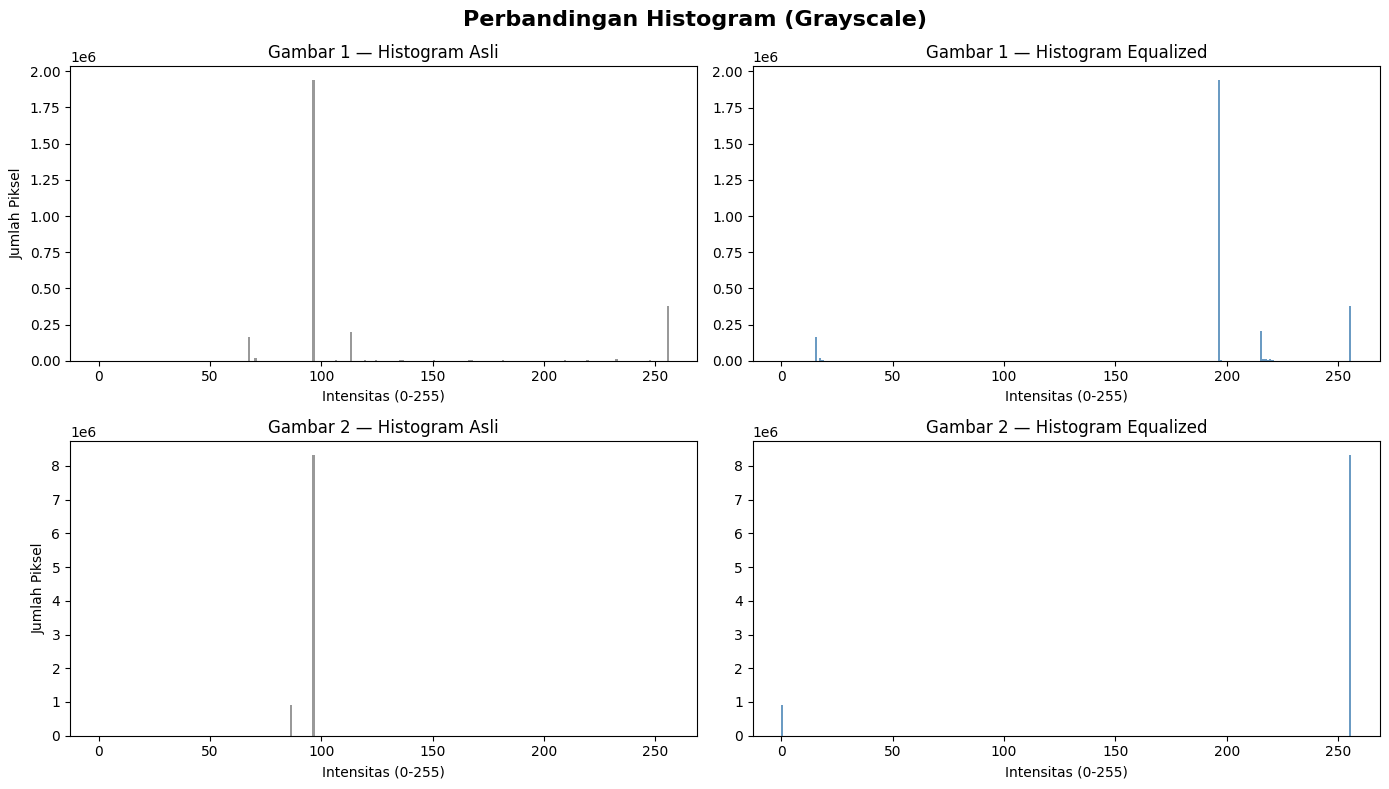

In [ ]:
# Visualisasi histogram sebelum & sesudah
fig, axes = plt.subplots(2, 2, figsize=(14, 8))
fig.suptitle('Perbandingan Histogram (Grayscale)', fontsize=16, fontweight='bold')

axes[0][0].hist(gray1.ravel(), bins=256, range=[0,256], color='gray', alpha=0.8)
axes[0][0].set_title('Gambar 1 — Histogram Asli'); axes[0][0].set_xlabel('Intensitas (0-255)'); axes[0][0].set_ylabel('Jumlah Piksel')

axes[0][1].hist(gray1_eq.ravel(), bins=256, range=[0,256], color='steelblue', alpha=0.8)
axes[0][1].set_title('Gambar 1 — Histogram Equalized'); axes[0][1].set_xlabel('Intensitas (0-255)')

axes[1][0].hist(gray2.ravel(), bins=256, range=[0,256], color='gray', alpha=0.8)
axes[1][0].set_title('Gambar 2 — Histogram Asli'); axes[1][0].set_xlabel('Intensitas (0-255)'); axes[1][0].set_ylabel('Jumlah Piksel')

axes[1][1].hist(gray2_eq.ravel(), bins=256, range=[0,256], color='steelblue', alpha=0.8)
axes[1][1].set_title('Gambar 2 — Histogram Equalized'); axes[1][1].set_xlabel('Intensitas (0-255)')

plt.tight_layout()
plt.show()

**Penjelasan Hasil — Histogram:**
Histogram menunjukkan distribusi intensitas piksel (sumbu X = nilai intensitas 0–255, sumbu Y = jumlah piksel). Pada histogram **asli**, distribusi biasanya menumpuk di rentang sempit. Setelah equalization, distribusi menjadi **lebih merata** dan menyebar ke seluruh range 0–255, menandakan gambar memiliki detail yang lebih kaya.

---
## 🔍 7. Filtering Spasial

**Konsep Dasar:**
Filtering spasial bekerja dengan **konvolusi** — menggeser kernel (matriks kecil) di atas setiap piksel gambar, lalu mengalikan nilai piksel dengan bobot kernel dan menjumlahkannya. Hasilnya adalah nilai piksel baru.

- **Smoothing** → kernel merata-ratakan piksel sekitar → hasil halus/blur
- **Sharpening** → kernel memperkuat perbedaan intensitas → tepi lebih tajam

### 7.1 Smoothing (Blur)

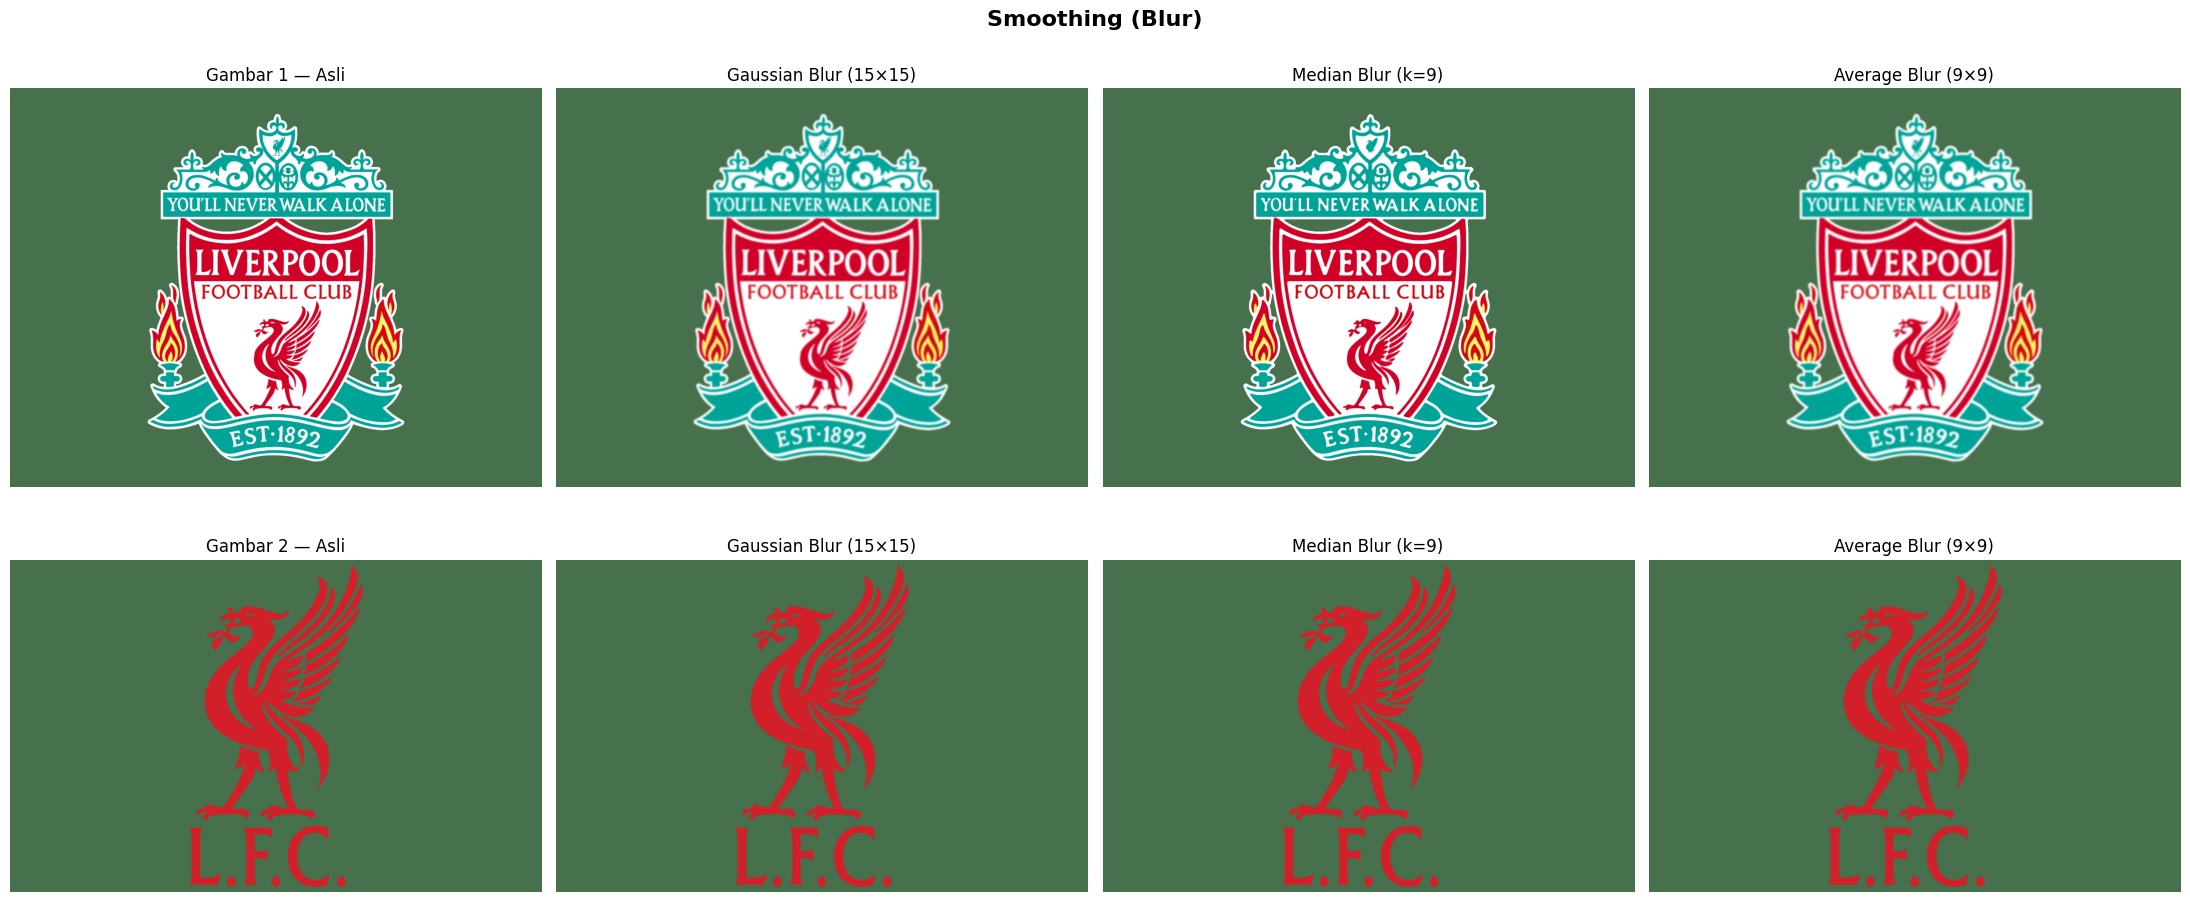

In [ ]:
img1_gauss  = cv2.GaussianBlur(img1, (15, 15), sigmaX=0)
img1_median = cv2.medianBlur(img1, 9)
img1_avg    = cv2.blur(img1, (9, 9))

img2_gauss  = cv2.GaussianBlur(img2, (15, 15), sigmaX=0)
img2_median = cv2.medianBlur(img2, 9)
img2_avg    = cv2.blur(img2, (9, 9))

fig, axes = plt.subplots(2, 4, figsize=(22, 10))
fig.suptitle('Smoothing (Blur)', fontsize=16, fontweight='bold')

for row, (orig, gauss, med, avg, label) in enumerate([
    (img1, img1_gauss, img1_median, img1_avg, 'Gambar 1'),
    (img2, img2_gauss, img2_median, img2_avg, 'Gambar 2')
]):
    axes[row][0].imshow(orig);  axes[row][0].set_title(f'{label} — Asli');        axes[row][0].axis('off')
    axes[row][1].imshow(gauss); axes[row][1].set_title('Gaussian Blur (15×15)'); axes[row][1].axis('off')
    axes[row][2].imshow(med);   axes[row][2].set_title('Median Blur (k=9)');     axes[row][2].axis('off')
    axes[row][3].imshow(avg);   axes[row][3].set_title('Average Blur (9×9)');    axes[row][3].axis('off')

plt.tight_layout()
plt.show()

**Penjelasan Hasil — Smoothing:**
- **Gaussian Blur** — Bobot kernel membentuk distribusi Gaussian (tengah lebih besar). Menghasilkan blur yang natural dan halus. Paling umum digunakan.
- **Median Blur** — Setiap piksel diganti dengan nilai *median* dari piksel-piksel tetangganya. Sangat efektif menghilangkan noise jenis *salt-and-pepper* karena tidak terpengaruh outlier.
- **Average Blur** — Setiap piksel diganti rata-rata dari tetangganya. Sederhana namun bisa membuat gambar terlihat kurang natural.

### 7.2 Sharpening

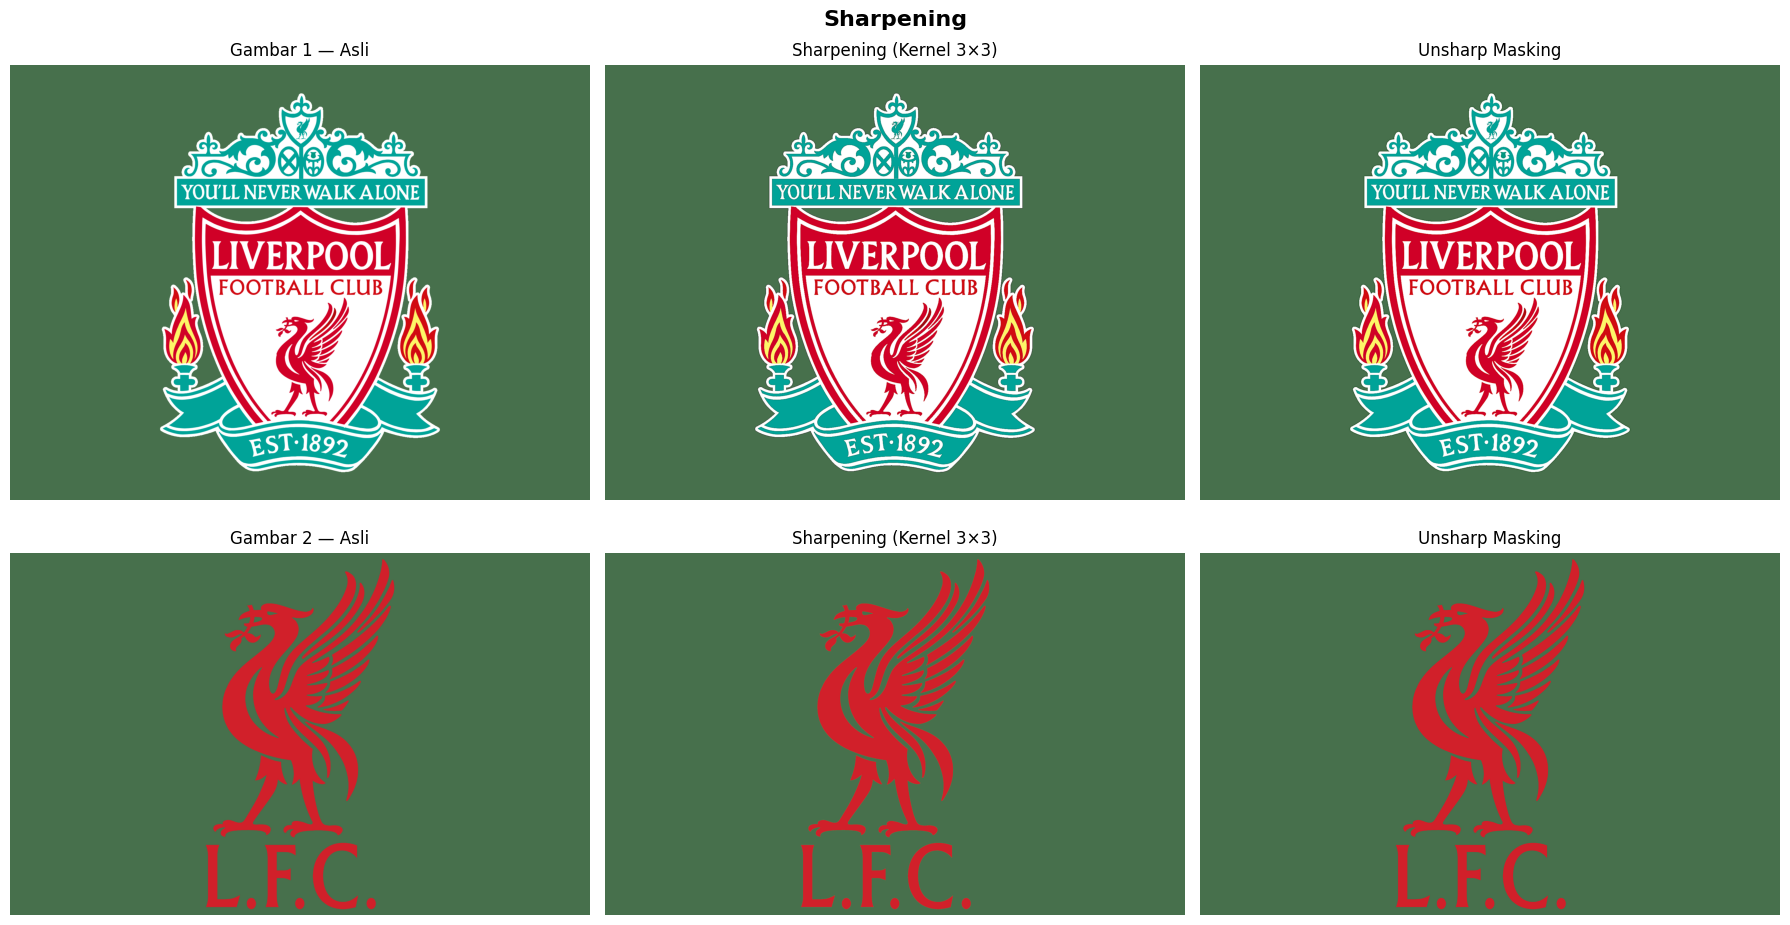

In [ ]:
kernel_sharpen = np.array([[ 0, -1,  0],
                            [-1,  5, -1],
                            [ 0, -1,  0]])

img1_sharp = cv2.filter2D(img1, -1, kernel_sharpen)
img2_sharp = cv2.filter2D(img2, -1, kernel_sharpen)

def unsharp_mask(img, sigma=1.0, strength=1.5):
    blurred = cv2.GaussianBlur(img, (0, 0), sigma)
    return cv2.addWeighted(img, 1 + strength, blurred, -strength, 0)

img1_unsharp = unsharp_mask(img1)
img2_unsharp = unsharp_mask(img2)

fig, axes = plt.subplots(2, 3, figsize=(18, 10))
fig.suptitle('Sharpening', fontsize=16, fontweight='bold')

for row, (orig, sharp, unsharp, label) in enumerate([
    (img1, img1_sharp, img1_unsharp, 'Gambar 1'),
    (img2, img2_sharp, img2_unsharp, 'Gambar 2')
]):
    axes[row][0].imshow(orig);    axes[row][0].set_title(f'{label} — Asli');         axes[row][0].axis('off')
    axes[row][1].imshow(sharp);   axes[row][1].set_title('Sharpening (Kernel 3×3)'); axes[row][1].axis('off')
    axes[row][2].imshow(unsharp); axes[row][2].set_title('Unsharp Masking');         axes[row][2].axis('off')

plt.tight_layout()
plt.show()

**Penjelasan Hasil — Sharpening:**
- **Kernel Sharpening** — Kernel `[[0,-1,0],[-1,5,-1],[0,-1,0]]` memperkuat perbedaan antara piksel pusat dengan tetangganya. Nilai tengah=5 mempertahankan piksel asli, nilai -1 di sekitar mengurangi pengaruh tetangga → tepi gambar menjadi lebih tajam.
- **Unsharp Masking** — Teknik: `sharp = original × (1+α) - blurred × α`. Gambar blur dikurangi dari gambar asli untuk mendapatkan komponen "detail", lalu ditambahkan kembali. Hasilnya lebih natural dan halus dibanding kernel langsung.

---
## ✅ Kesimpulan

| No | Teknik | Fungsi Utama | Fungsi OpenCV |
|----|--------|-------------|---------------|
| 1 | Konversi Grayscale | Menyederhanakan citra menjadi 1 kanal intensitas | `cv2.cvtColor()` |
| 2 | Brightness | Mengatur kecerahan gambar dengan menambah/mengurangi nilai piksel | `cv2.convertScaleAbs()` |
| 3 | Contrast | Mengatur rentang intensitas piksel dengan perkalian | `cv2.convertScaleAbs()` |
| 4 | Translasi | Menggeser posisi gambar secara horizontal/vertikal | `cv2.warpAffine()` |
| 5 | Rotasi | Memutar gambar terhadap titik pusat | `cv2.getRotationMatrix2D()` |
| 6 | Scaling | Memperbesar atau memperkecil dimensi gambar | `cv2.resize()` |
| 7 | Flipping | Membalik gambar secara horizontal/vertikal | `cv2.flip()` |
| 8 | Histogram Equalization | Meratakan distribusi intensitas piksel | `cv2.equalizeHist()` |
| 9 | Smoothing (Blur) | Menghaluskan gambar dan menghilangkan noise | `cv2.GaussianBlur()` |
| 10 | Sharpening | Mempertegas tepi dan detail gambar | `cv2.filter2D()` |

---
*Notebook ini mengimplementasikan konsep dasar pengolahan citra digital menggunakan Python, OpenCV, dan NumPy di Google Colab.*